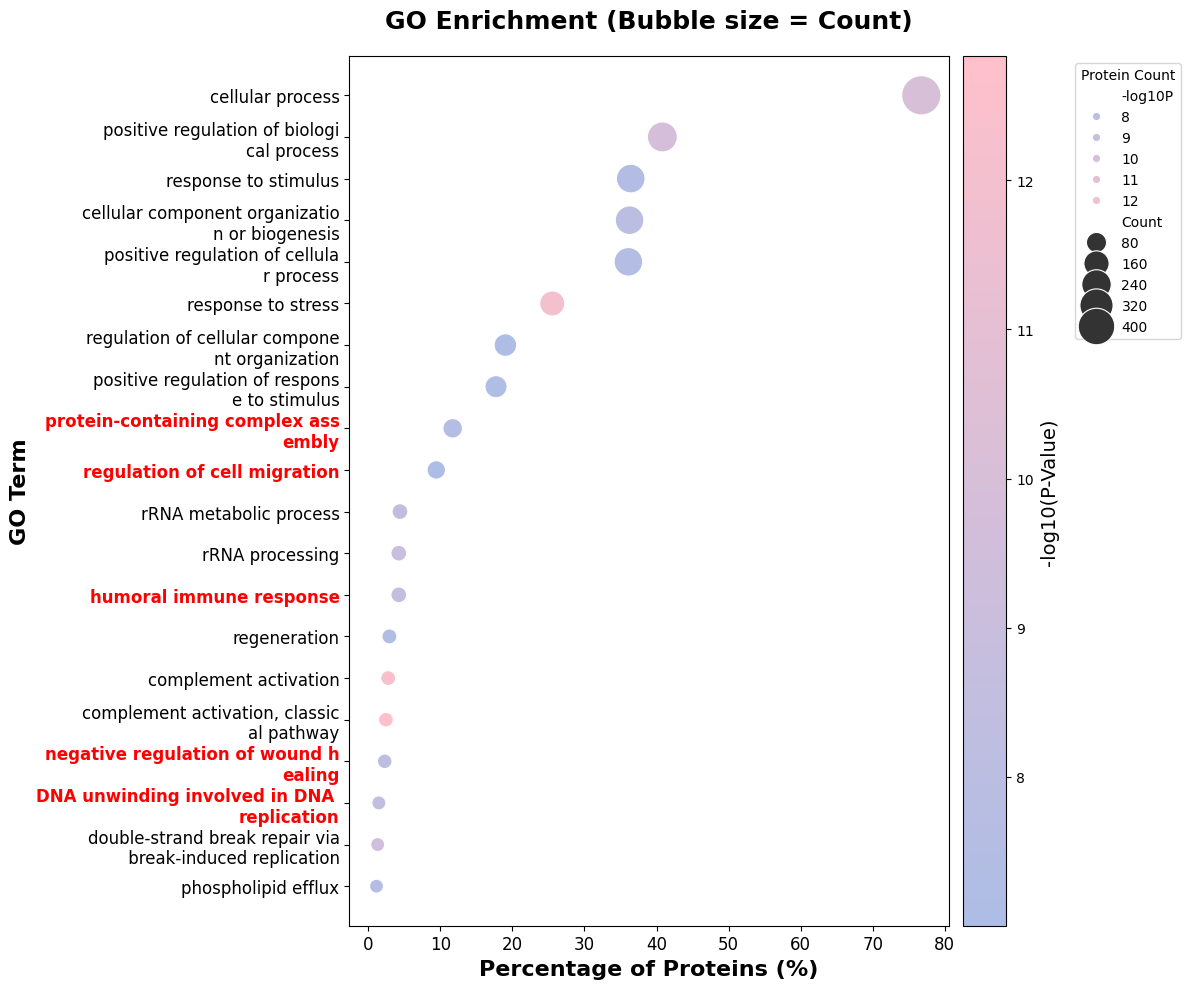

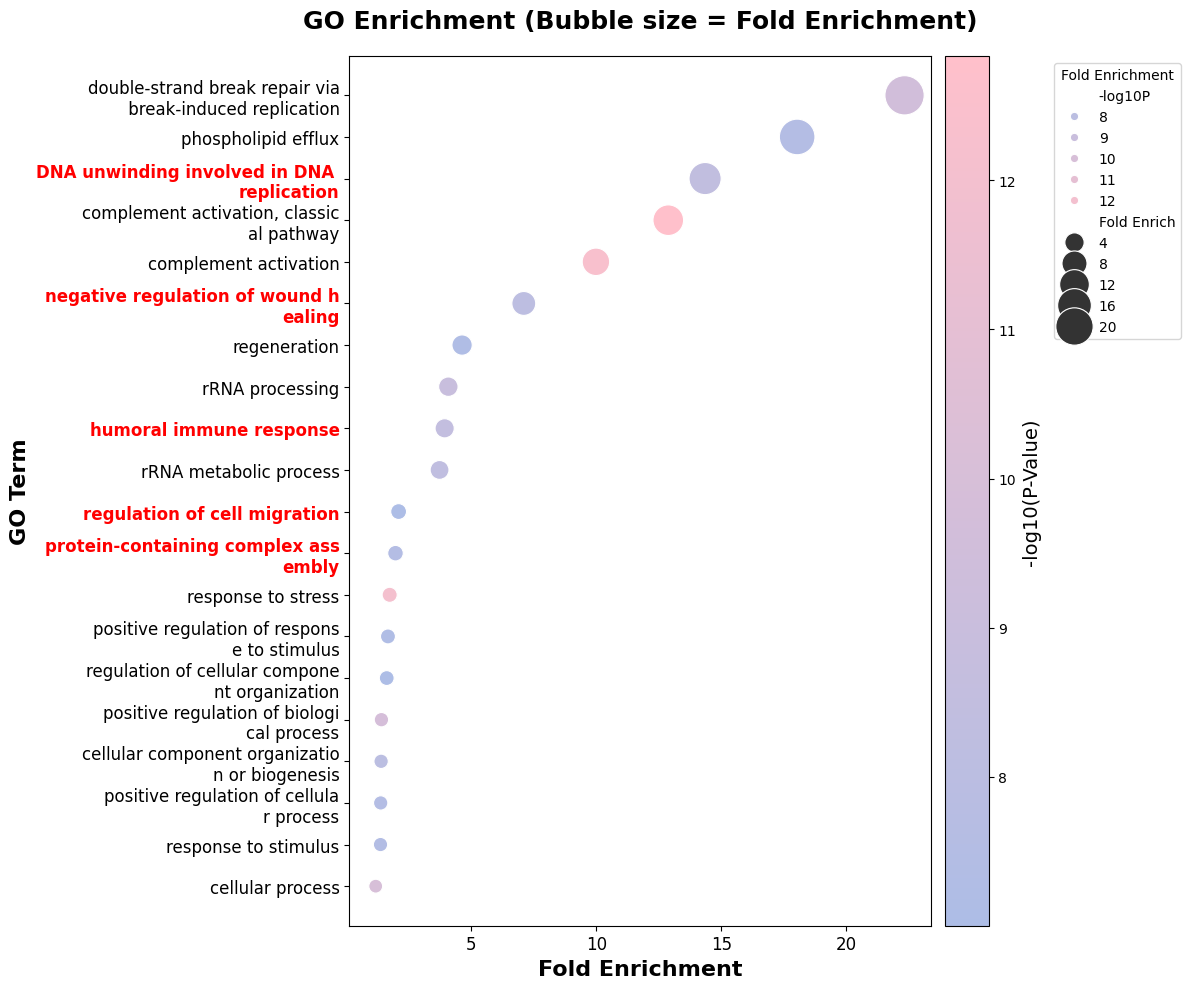

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable

# ==================== 第 1 步：设置文件路径 ====================
# 这里填入你终端输出的那个真实本地文件路径（例如选 BP 或者 CC 的 csv）
# 注意：路径前面的 'r' 不要丢掉，防止转义
file_path = r"E:\python-pro\ICA\组学分析\danbai_data\raw data\20241107-CQT2024101111-F001-4D Direct DIA定量蛋白组-分析报告\20241107-CQT2024101111-F001-4D Direct DIA定量蛋白组-分析报告\4.Diff_Bioinformatics\1.GO_Enrichment\ABs_vs_dABs\ABs_vs_dABs_GO_Enrichment_BIOLOGICAL_PROCESS.csv"

# 这里填入你需要标记为红色的目标蛋白/GO名单 Excel 路径
labels_file_path = r"C:\Users\Administrator\Desktop\target_go_names.xlsx"

# ==================== 第 2 步：读取与清洗数据 ====================
go_enrich = pd.read_csv(file_path, float_precision='high')

# 过滤 Depth = 0 这种没有意义的顶层节点
if 'Depth' in go_enrich.columns:
    go_enrich = go_enrich[go_enrich['Depth'] != 0]

# P-Value 转数值并过滤
go_enrich['P-Value'] = pd.to_numeric(go_enrich['P-Value'], errors='coerce')
filtered_go = go_enrich.dropna(subset=['P-Value']).copy()

# 核心筛选逻辑：先看 < 0.05 的，不够3个再放宽到 < 0.1
temp_go = filtered_go[filtered_go['P-Value'] < 0.05]
if len(temp_go) < 3:
    temp_go = filtered_go[filtered_go['P-Value'] < 0.1]

# 取前 20 个 P-Value 最小的条目
top_20_go = temp_go.nsmallest(20, 'P-Value').copy()
top_20_go['-log10P'] = -np.log10(top_20_go['P-Value'])

# ==================== 第 3 步：智能解析 Count, Percent, Fold Enrich ====================
# 通常公司给的富集表中，Test Ratio 是形如 "15/300" 的字符串 (15个在GO里，300是总差异蛋白)
def parse_ratio(ratio_val):
    try:
        if isinstance(ratio_val, str) and '/' in ratio_val:
            num, den = ratio_val.split('/')
            num, den = float(num), float(den)
            return num, (num / den) * 100  # 返回 (Count, Percentage)
        else:
            # 如果已经是纯数字(例如 0.05)，则返回 Count无从得知(设为NaN)，百分比为 0.05*100
            val = float(ratio_val)
            return val, val * 100 
    except:
        return np.nan, np.nan

# 提取特征
if 'Test Ratio' in top_20_go.columns:
    top_20_go[['Count', 'Percentage']] = top_20_go.apply(lambda row: pd.Series(parse_ratio(row['Test Ratio'])), axis=1)
elif 'Count' in top_20_go.columns: # 如果表格直接提供了Count列
    top_20_go['Count'] = pd.to_numeric(top_20_go['Count'], errors='coerce')
    top_20_go['Percentage'] = top_20_go['Count'] # 粗略代替

if 'Fold Enrich' in top_20_go.columns:
    top_20_go['Fold Enrich'] = pd.to_numeric(top_20_go['Fold Enrich'], errors='coerce')
elif 'Fold Enrichment' in top_20_go.columns:
    top_20_go['Fold Enrich'] = pd.to_numeric(top_20_go['Fold Enrichment'], errors='coerce')

# ==================== 第 4 步：预处理红色标签 & 文字换行 ====================
try:
    labels_df = pd.read_excel(labels_file_path)
    labels_go_names_set = set(labels_df['GO Name'].astype(str).tolist())
except Exception as e:
    print(f"警告：无法读取红色标签文件，所有的字将保持黑色。错误原因: {e}")
    labels_go_names_set = set()

def wrap_text(text, width=30):
    text = str(text)
    return '\n'.join([text[i:i+width] for i in range(0, len(text), width)])

# 色系设置
cmap_name = "light_blue_to_pink"
cmap = LinearSegmentedColormap.from_list(cmap_name, ["#ADBDE6", "pink"])
norm = Normalize(vmin=top_20_go['-log10P'].min(), vmax=top_20_go['-log10P'].max())
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

# =====================================================================
#                        画图 1：X为占比，点大小为数量
# =====================================================================
df_fig1 = top_20_go.sort_values(by='Percentage', ascending=False) # 按占比从大到小排
df_fig1['GO Name Wrapped'] = [wrap_text(name) for name in df_fig1['GO Name']]

fig1, ax1 = plt.subplots(figsize=(12, 10))
sc1 = sns.scatterplot(
    data=df_fig1,
    x='Percentage',
    y='GO Name Wrapped',
    size='Count',
    hue='-log10P',
    sizes=(100, 800), # 气泡大小范围
    palette=cmap,
    ax=ax1
)

ax1.set_xlabel('Percentage of Proteins (%)', fontsize=16, fontweight='bold')
ax1.set_ylabel('GO Term', fontsize=16, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# 修改红色标签
for text in ax1.get_yticklabels():
    raw_name = text.get_text().replace('\n', '') # 还原去除换行符的比对
    if any(marked_name in raw_name for marked_name in labels_go_names_set):
        text.set_color('red')
        text.set_fontweight('bold')

# 美化图例与Colorbar
cbar1 = fig1.colorbar(sm, ax=ax1, pad=0.02)
cbar1.set_label('-log10(P-Value)', fontsize=14)
handles, labels = sc1.get_legend_handles_labels()
ax1.legend(handles, labels, bbox_to_anchor=(1.2, 1), loc='upper left', title="Protein Count")
plt.title("GO Enrichment (Bubble size = Count)", fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()


# =====================================================================
#                      画图 2：X为富集倍数，点大小为富集倍数
# =====================================================================
df_fig2 = top_20_go.sort_values(by='Fold Enrich', ascending=False) # 按富集倍数从大到小排
df_fig2['GO Name Wrapped'] = [wrap_text(name) for name in df_fig2['GO Name']]

fig2, ax2 = plt.subplots(figsize=(12, 10))
sc2 = sns.scatterplot(
    data=df_fig2,
    x='Fold Enrich',
    y='GO Name Wrapped',
    size='Fold Enrich',
    hue='-log10P',
    sizes=(100, 800), 
    palette=cmap,
    ax=ax2
)

ax2.set_xlabel('Fold Enrichment', fontsize=16, fontweight='bold')
ax2.set_ylabel('GO Term', fontsize=16, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# 修改红色标签
for text in ax2.get_yticklabels():
    raw_name = text.get_text().replace('\n', '') 
    if any(marked_name in raw_name for marked_name in labels_go_names_set):
        text.set_color('red')
        text.set_fontweight('bold')

# 美化图例与Colorbar
cbar2 = fig2.colorbar(sm, ax=ax2, pad=0.02)
cbar2.set_label('-log10(P-Value)', fontsize=14)
handles2, labels2 = sc2.get_legend_handles_labels()
ax2.legend(handles2, labels2, bbox_to_anchor=(1.2, 1), loc='upper left', title="Fold Enrichment")
plt.title("GO Enrichment (Bubble size = Fold Enrichment)", fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()

# ==================== 第 5 步：同时展示两张图 ====================
plt.show()